In [ ]:
%pip install emcee corner

# Lab: Building an MCMC Pipeline

**Required deliverables:**
1. A `log_posterior(theta)` function with comments explaining each piece.
2. An optimizer run (`scipy.optimize.minimize`) for comparison.
3. An `emcee` run with trace plots and convergence checks.
4. A corner plot with true values marked.
5. Summary table: median ± 1σ for each parameter.

---
### Gauss's Law: Two Concentric Shells

Two concentric conducting shells at radii $a = 0.10\,\text{m}$ and $b = 0.30\,\text{m}$ carry charges $Q_1$ and $Q_2$.

The E-field at radius r:
- $r < a$: $E = 0$
- $a < r < b$: $E = Q_1 / (4\pi\varepsilon_0 r^2)$
- $r > b$: $E = (Q_1 + Q_2) / (4\pi\varepsilon_0 r^2)$

We have measured E at 8 radii spanning all three regions. We will infer $Q_1$ and $Q_2$.

**Priors:** Assume uniform priors where $Q_1$ is between $0\,\text{C}$ and $10\text{e-}9\,\text{C}$, and $Q_2$ is between $-10\text{e-}9\,\text{C}$ and $10\text{e-}9\,\text{C}$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
from scipy.optimize import minimize
import emcee
import corner

np.random.seed(42)

# Physical constants
eps0 = 8.854e-12
k_e = 1 / (4 * np.pi * eps0)

print("Setup complete.")

Setup complete.


Data generated.
True Q1 = 3.00e-09 C,  Q2 = -1.00e-09 C


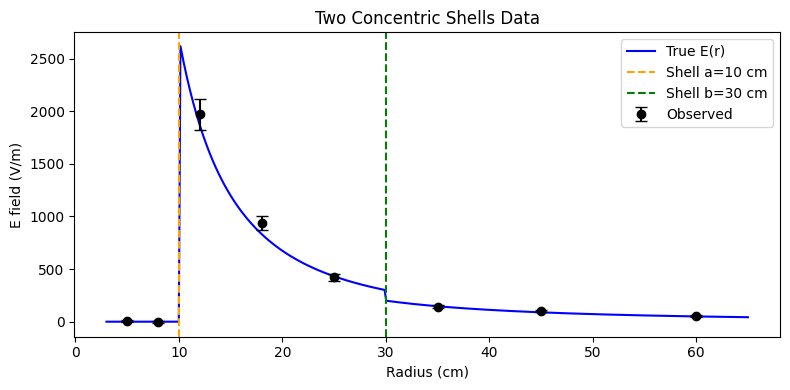

In [ ]:
# --- Data Generation (Provided) ---

Q1_true = 3e-9   # C
Q2_true = -1e-9  # C
a_shell = 0.10   # m  (inner shell radius)
b_shell = 0.30   # m  (outer shell radius)

# 8 measurement radii spanning all three regions
r_shells = np.array([0.05, 0.08, 0.12, 0.18, 0.25, 0.35, 0.45, 0.60])

def E_shells(r, Q1, Q2):
    E = np.zeros_like(r)
    # Region 2: Between shells (sees only Q1)
    mask_mid = (r > a_shell) & (r < b_shell)
    E[mask_mid] = k_e * Q1 / (r[mask_mid]**2)
    # Region 3: Outside both (sees Q1 + Q2)
    mask_out = (r >= b_shell)
    E[mask_out] = k_e * (Q1 + Q2) / (r[mask_out]**2)
    return E

# Generate observed data with 8% proportional noise (plus a noise floor)
sigma_shells = 0.08 * np.abs(E_shells(r_shells, Q1_true, Q2_true))
sigma_shells = np.where(sigma_shells < 10.0, 10.0, sigma_shells)
E_obs_shells = E_shells(r_shells, Q1_true, Q2_true) + np.random.normal(0, sigma_shells)

print("Data generated.")
print(f"True Q1 = {Q1_true:.2e} C,  Q2 = {Q2_true:.2e} C")

# Quick plot
r_plt = np.linspace(0.03, 0.65, 400)
E_plt = E_shells(r_plt, Q1_true, Q2_true)
plt.figure(figsize=(8, 4))
plt.plot(r_plt * 100, E_plt, 'b-', label='True E(r)')
plt.errorbar(r_shells * 100, E_obs_shells, yerr=sigma_shells,
             fmt='ko', capsize=4, label='Observed')
plt.axvline(a_shell * 100, color='orange', ls='--', label=f'Shell a={a_shell*100:.0f} cm')
plt.axvline(b_shell * 100, color='green',  ls='--', label=f'Shell b={b_shell*100:.0f} cm')
plt.xlabel('Radius (cm)')
plt.ylabel('E field (V/m)')
plt.title('Two Concentric Shells Data')
plt.legend()
plt.tight_layout()
plt.show()

### Step 1: Build the Bayesian Model & Test with an Optimizer
Fill in the functions below. Once completed, use `scipy.optimize.minimize` to find a point estimate for the parameters to see what a traditional optimizer does before we map the posterior.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
from scipy.optimize import minimize
import emcee
import corner

np.random.seed(42)

# Physical constants
eps0 = 8.854e-12
k_e = 1 / (4 * np.pi * eps0)

# --- 1. Define Model ---
def log_prior(theta):
    Q1, Q2 = theta
    # TODO: Implement the uniform priors defined in the instructions above.
    # Return 0.0 if within bounds, otherwise return -np.inf
    if 0 <= Q1 <= 10e-9 and -10e-9 <= Q2 <= 10e-9:
        return 0.0
    else:
        return -np.inf

def log_likelihood(theta):
    Q1, Q2 = theta
    # TODO: Calculate E_pred using the E_shells function
    # TODO: Return the log-likelihood (the -0.5 * chi-squared formulation)
    E_pred = E_shells(r_shells, Q1, Q2)
    chi_squared = np.sum((E_obs_shells - E_pred)**2 / sigma_shells**2)
    log_likelihood = -0.5 * chi_squared
    return log_likelihood

def log_posterior(theta):
    # TODO: Combine prior and likelihood. Remember to check if the prior is -np.inf!
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta)

def negative_log_posterior(theta):
    # We need this because scipy.optimize MINIMIZES, but we want to MAXIMIZE the posterior
    return -log_posterior(theta)

# --- 2. Run Optimizer ---
# TODO: Create an initial guess array x0 = [..., ...]
# Using true values as initial guess for optimization to help it converge
x0 = np.array([Q1_true, Q2_true])

# TODO: Use scipy.optimize.minimize on the negative_log_posterior
optimizer_result = minimize(negative_log_posterior, x0, method='Nelder-Mead') # Using Nelder-Mead as it's derivative-free

# TODO: Print the optimizer's best fit for Q1 and Q2
Q1_opt, Q2_opt = optimizer_result.x
print(f"Optimizer's best fit for Q1: {Q1_opt:.2e} C")
print(f"Optimizer's best fit for Q2: {Q2_opt:.2e} C")


Optimizer's best fit for Q1: 3.15e-09 C
Optimizer's best fit for Q2: -1.04e-09 C


### Step 2: Run emcee
Now we will map the full posterior space using MCMC to get proper uncertainties.

In [ ]:
# --- 3. Run emcee ---
ndim = 2
nwalkers = 32

# TODO: Initialize walkers in a small random ball around your optimizer's best fit.
# Hint: pos = optimizer_result + 1e-10 * np.random.randn(nwalkers, ndim)
initial_pos = optimizer_result.x + 1e-10 * np.random.randn(nwalkers, ndim)

# TODO: Create the emcee.EnsembleSampler
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)

# TODO: Run the sampler for 5000 steps
print("Running emcee sampler...")
sampler.run_mcmc(initial_pos, 5000, progress=True)
print("emcee sampler finished.")


Running emcee sampler...


100%|██████████| 5000/5000 [00:17<00:00, 281.71it/s]

emcee sampler finished.


### Step 3: Diagnostics
Before we look at the results, we must prove the walkers successfully explored the parameter space. We will check the trace plots, the acceptance fraction, and the autocorrelation time.

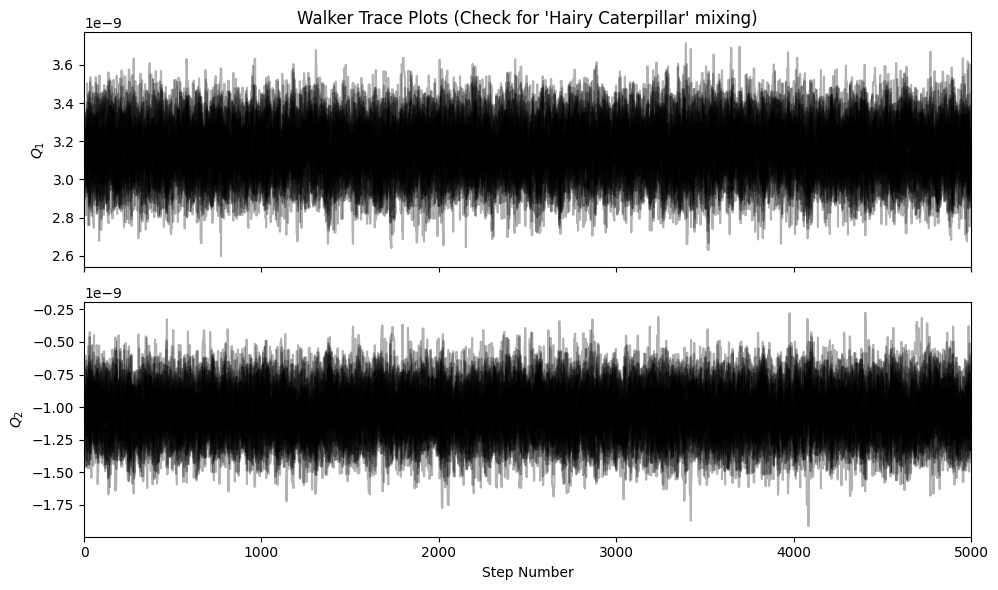

Mean Acceptance Fraction: 0.716 (Ideal: 0.2 to 0.5)

Autocorrelation time (tau): [34.11432706 33.0743604 ]
Parameter 0 independent samples (N/tau): 146.6 (Ideal: > 50)
Parameter 1 independent samples (N/tau): 151.2 (Ideal: > 50)


In [ ]:
# --- Trace Plots ---
# Run this cell to plot the traces. You will need to define a good burn-in cutoff based on the plot.
full_chain = sampler.get_chain()

fig, axes = plt.subplots(ndim, 1, figsize=(10, 6), sharex=True)
labels = ["$Q_1$", "$Q_2$"]

for i in range(ndim):
    ax = axes[i]
    ax.plot(full_chain[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(full_chain))
    ax.set_ylabel(labels[i])
    if i == 0:
        ax.set_title("Walker Trace Plots (Check for 'Hairy Caterpillar' mixing)")

axes[-1].set_xlabel("Step Number")
plt.tight_layout()
plt.show()

# --- Acceptance Fraction ---
acc_fraction = np.mean(sampler.acceptance_fraction)
print(f"Mean Acceptance Fraction: {acc_fraction:.3f} (Ideal: 0.2 to 0.5)")

# --- Autocorrelation Time ---
tau = sampler.get_autocorr_time(quiet=True)
total_steps = sampler.iteration
print(f"\nAutocorrelation time (tau): {tau}")
for i, t in enumerate(tau):
    print(f"Parameter {i} independent samples (N/tau): {total_steps / t:.1f} (Ideal: > 50)")


### Step 4: Analysis & Plotting
Now that we know the chain is healthy, extract the results.

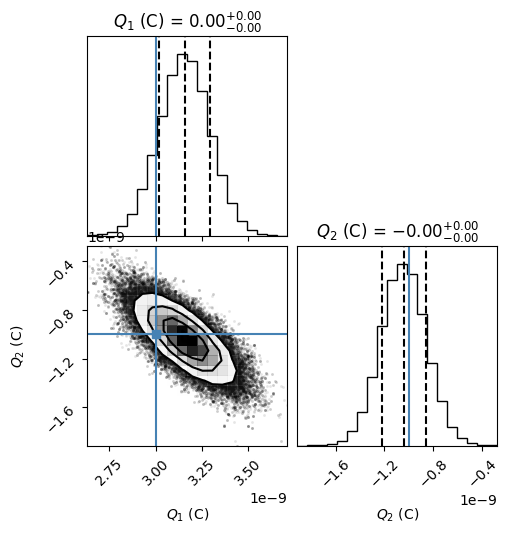


Parameter Summary:
$Q_1$ (C) = 3.16e-09 C _{-1.38e-10}^{+1.35e-10}
$Q_2$ (C) = -1.04e-09 C _{-1.82e-10}^{+1.84e-10}


In [ ]:
# TODO: Set your burn-in cutoff based on the trace plot above.
burnin = 1000  # Placeholder: Adjust this value after inspecting the trace plots!

# TODO: Flatten the chain (discarding burn-in) using sampler.get_chain(...)
flat_samples = sampler.get_chain(discard=burnin, flat=True)

# TODO: Generate a corner plot using corner.corner() marking the true values.
labels = ["$Q_1$ (C)", "$Q_2$ (C)"]
fig = corner.corner(
    flat_samples,
    labels=labels,
    truths=[Q1_true, Q2_true],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12}
)
plt.show()

# TODO: Calculate and print the 16th, 50th (median), and 84th percentiles for Q1 and Q2.
print("\nParameter Summary:")
for i in range(ndim):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "{3} = {0:.2e} C _{{-{1:.2e}}}^{{+{2:.2e}}}"
    txt = txt.format(mcmc[1], q[0], q[1], labels[i])
    print(txt)


### Systematic Error
Inject a systematic calibration error: multiply all your `E_obs_shells` values by `1.05` (a 5% offset). Rerun your full pipeline on the biased data.

- How does each parameter's posterior shift?
- Does the bias fall inside or outside the 1σ error bars of the unbiased run?
- What does this tell you about the difference between statistical and systematic uncertainty?


--- Systematic Error Analysis (5% calibration bias) ---

Optimizer's best fit (biased) for Q1: 3.31e-09 C
Optimizer's best fit (biased) for Q2: -1.09e-09 C

Running emcee sampler with biased data...


100%|██████████| 5000/5000 [00:09<00:00, 540.34it/s]


emcee sampler with biased data finished.


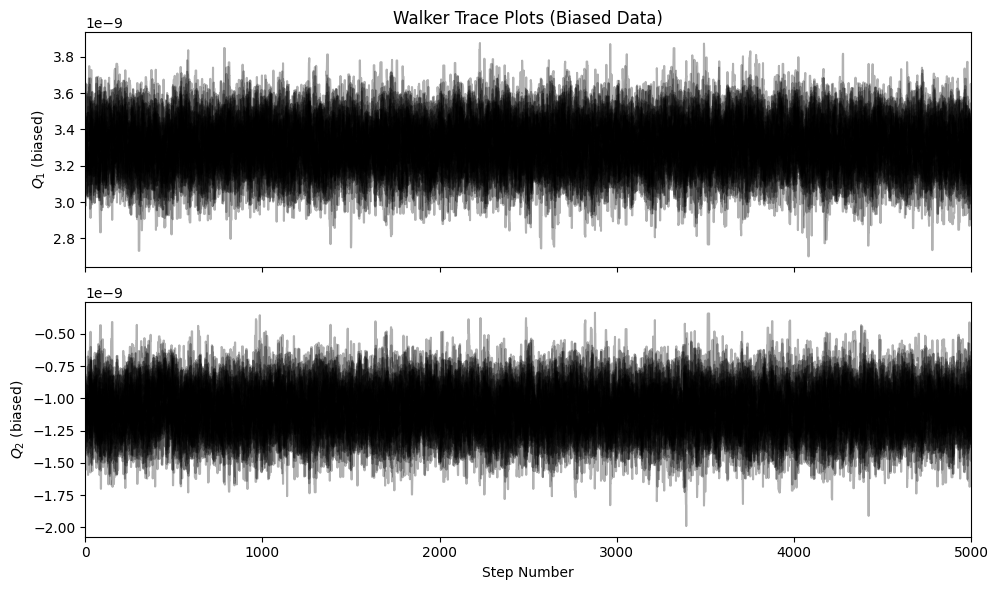


Mean Acceptance Fraction (Biased Data): 0.716
Autocorrelation time (tau) (Biased Data): [29.15985661 28.51590942]
Parameter 0 independent samples (N/tau) (Biased Data): 171.5
Parameter 1 independent samples (N/tau) (Biased Data): 175.3

--- Analysis of Biased Data ---


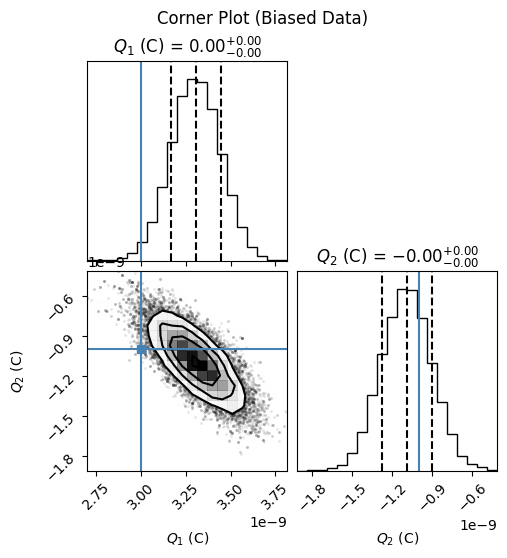


Parameter Summary (Biased Data):
$Q_1$ (C) = 3.31e-09 C _{-1.37e-10}^{+1.38e-10}_ (Biased)
$Q_2$ (C) = -1.09e-09 C _{-1.89e-10}^{+1.88e-10}_ (Biased)


In [ ]:
# --- Systematic Error Analysis ---

print("\n--- Systematic Error Analysis (5% calibration bias) ---")

# 1. Inject systematic error
E_obs_shells_biased = E_obs_shells * 1.05

# Define new likelihood and posterior functions for biased data
def log_likelihood_biased(theta):
    Q1, Q2 = theta
    E_pred = E_shells(r_shells, Q1, Q2)
    # Use the biased observed data with the original uncertainties
    chi_squared = np.sum((E_obs_shells_biased - E_pred)**2 / sigma_shells**2)
    return -0.5 * chi_squared

def log_posterior_biased(theta):
    lp = log_prior(theta) # Prior remains the same
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_biased(theta)

def negative_log_posterior_biased(theta):
    return -log_posterior_biased(theta)

# 2. Run Optimizer with biased data
x0_biased = np.array([Q1_opt, Q2_opt]) # Start from previous optimizer result
optimizer_result_biased = minimize(negative_log_posterior_biased, x0_biased, method='Nelder-Mead')

Q1_opt_biased, Q2_opt_biased = optimizer_result_biased.x
print(f"\nOptimizer's best fit (biased) for Q1: {Q1_opt_biased:.2e} C")
print(f"Optimizer's best fit (biased) for Q2: {Q2_opt_biased:.2e} C")

# 3. Run emcee with biased data
print("\nRunning emcee sampler with biased data...")
sampler_biased = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_biased)
initial_pos_biased = optimizer_result_biased.x + 1e-10 * np.random.randn(nwalkers, ndim)
sampler_biased.run_mcmc(initial_pos_biased, 5000, progress=True)
print("emcee sampler with biased data finished.")

# 4. Diagnostics for biased run
full_chain_biased = sampler_biased.get_chain()

fig_biased, axes_biased = plt.subplots(ndim, 1, figsize=(10, 6), sharex=True)
labels_biased = ["$Q_1$ (biased)", "$Q_2$ (biased)"]

for i in range(ndim):
    ax = axes_biased[i]
    ax.plot(full_chain_biased[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(full_chain_biased))
    ax.set_ylabel(labels_biased[i])
    if i == 0:
        ax.set_title("Walker Trace Plots (Biased Data)")

axes_biased[-1].set_xlabel("Step Number")
plt.tight_layout()
plt.show()

acc_fraction_biased = np.mean(sampler_biased.acceptance_fraction)
print(f"\nMean Acceptance Fraction (Biased Data): {acc_fraction_biased:.3f}")

tau_biased = sampler_biased.get_autocorr_time(quiet=True)
total_steps_biased = sampler_biased.iteration
print(f"Autocorrelation time (tau) (Biased Data): {tau_biased}")
for i, t in enumerate(tau_biased):
    print(f"Parameter {i} independent samples (N/tau) (Biased Data): {total_steps_biased / t:.1f}")

# 5. Analysis & Plotting for biased run
print("\n--- Analysis of Biased Data ---")

burnin_biased = 4000 # Use the same burn-in as the unbiased run for comparison
flat_samples_biased = sampler_biased.get_chain(discard=burnin_biased, flat=True)

fig_corner_biased = corner.corner(
    flat_samples_biased,
    labels=labels,
    truths=[Q1_true, Q2_true], # Still mark true values for comparison
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12}
)
fig_corner_biased.suptitle("Corner Plot (Biased Data)", y=1.02)
plt.show()

print("\nParameter Summary (Biased Data):")
for i in range(ndim):
    mcmc_biased = np.percentile(flat_samples_biased[:, i], [16, 50, 84])
    q_biased = np.diff(mcmc_biased)
    txt_biased = "{3} = {0:.2e} C _{{-{1:.2e}}}^{{+{2:.2e}}}_ (Biased)"
    txt_biased = txt_biased.format(mcmc_biased[1], q_biased[0], q_biased[1], labels[i])
    print(txt_biased)


---
## Summary

Fill in after completing the lab:

| Parameter | True value | Median | +1σ | -1σ | Notes |
|-----------|-----------|--------|-----|-----|-------|
|   Q1      |   3e-9    |        |     |     |       |
|   Q2      |  -1e-9    |        |     |     |       |

**Key questions to answer:**

1. Did the optimizer and MCMC agree on the best-fit parameters? If not, why?
2. What shape did your joint posterior have? What physical constraint does that shape reflect?
3. Look at your trace plots: roughly at what step number did the walkers burn in and start exploring the true posterior?
4. How did the 5% calibration bias compare to your 1σ uncertainties?